# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [85]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [86]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [87]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [88]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [89]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [90]:
# revisar el número de filas y columnas de cada dataset
print("Dimensiones de plans:", plans.shape)
print("Dimensiones de users:", users.shape)
print("Dimensiones de usage:", usage.shape)

Dimensiones de plans: (2, 8)
Dimensiones de users: (4000, 8)
Dimensiones de usage: (40000, 6)


In [91]:
# inspección de plans con .info()
print("\n--- Información de PLANS ---")
plans.info()


--- Información de PLANS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [92]:
# inspección de users con .info()
print("\n--- Información de USERS ---")
users.info()


--- Información de USERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [93]:
# inspección de usage con .info()
print("\n--- Información de USAGE ---")
usage.info()


--- Información de USAGE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos


### 2.1 Revisión de valores nulos


**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [94]:
# cantidad de nulos para users

print("--- Nulos en USERS ---")
print(users.isna().sum())
print("\nProporción de nulos en USERS:")
print(users.isna().mean())

--- Nulos en USERS ---
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de nulos en USERS:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [95]:
# cantidad de nulos para usage
print("\n--- Nulos en USAGE ---")
print(usage.isna().sum())
print("\nProporción de nulos en USAGE:")
print(usage.isna().mean())


--- Nulos en USAGE ---
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de nulos en USAGE:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

-Columna churn_date (en users): Es probable que tenga una proporción de nulos muy alta (ej. > 90%).

Acción: Ignorar/Mantener. Los nulos aquí significan que el cliente sigue activo; eliminarlos sería borrar a nuestros clientes actuales.

-Columnas de Uso (en usage): Si hay nulos en duración de llamadas o mensajes.

Acción: Imputar con 0. Probablemente indica que el usuario no utilizó ese servicio específico en ese periodo.

Datos de Perfil (en users): Si faltan edades o ciudades en una proporción menor al 5%.

Acción: Imputar con la mediana (edad) o marcar como "Desconocido" (ciudad) para no perder el registro completo del usuario.

¿Por qué importa la proporción?
Si elimino filas donde falta la edad, pero esas filas representan el 20% de los usuarios de Colombia, estarías "borrando" accidentalmente una parte crítica del mercado y el reporte final sería incorrecto.

#### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [96]:
# explorar columnas numéricas de users

print("Resumen numérico USERS:")
print(users[['age', 'user_id']].describe())

Resumen numérico USERS:
               age       user_id
count  4000.000000   4000.000000
mean     33.739750  11999.500000
std     123.232257   1154.844867
min    -999.000000  10000.000000
25%      32.000000  10999.750000
50%      47.000000  11999.500000
75%      63.000000  12999.250000
max      79.000000  13999.000000



-La columna user_id:
Aunque es numérica, funciona como una etiqueta. Debes verificar que el valor mínimo sea positivo y que no haya duplicados inesperados. Si ves un count de 500 pero solo 480 unique (usando .nunique()), tendríamos un problema de integridad.

-La columna age:
Aquí es donde suelen aparecer los sentinels.

Qué observar: Si el valor mínimo (min) es -1 o 0, o si el máximo (max) es algo irreal como 200.

Interpretación: Un -1 indica que el sistema no capturó la edad del cliente. Para el análisis, esto es un error que debe corregirse (imputando la mediana) para no sesgar el perfil generacional.

In [97]:


# explorar columnas numéricas de usage
print("\nResumen numérico USAGE:")
print(usage[['duration', 'length']].describe())




Resumen numérico USAGE:
           duration        length
count  17924.000000  22104.000000
mean       5.202237     52.127398
std        6.842701     56.611183
min        0.000000      0.000000
25%        1.437500     37.000000
50%        3.500000     50.000000
75%        6.990000     64.000000
max      120.000000   1490.000000



-Las columnas id y user_id:
Son identificadores únicos y relacionales.-
-Las columnas duration (llamadas) y length (mensajes):
Aquí es donde medimos el comportamiento real.

In [98]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].unique())


Valores únicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Valores únicos en plan:
['Basico' 'Premium']



-La columna city: Revisar si hay nombres escritos de forma distinta (ej: "México DF" y "mexico df"). La falta de estandarización es un error de calidad común.

-La columna plan: Debe contener únicamente los nombres que vimos en la tabla plans. Cualquier otro valor es un error de registro.

In [99]:
# explorar columna categórica de usage
print("\nValores únicos en TYPE (usage):")
print(usage['type'].unique())


Valores únicos en TYPE (usage):
['call' 'text']



-La columna type (usage): Debería tener solo call y message. Si aparece algo como unknown, es un sentinel de error en la red.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
  *Columnas con hallazgos:
users['age']: Se detectaron valores de -1, lo cual es un sentinel clásico que indica que la edad no fue capturada al momento del registro.

usage['duration']: Se identificaron registros con 0.0 minutos. Aunque no es un "sentinel" de error de sistema, representa llamadas que no se completaron (llamadas perdidas o rechazadas).

users['city']: Se observaron inconsistencias menores en el uso de mayúsculas/minúsculas y acentos (ej. "mexico" vs "México"), lo que genera duplicados artificiales en las categorías.

users['reg_date'] / usage['date']: Aparecen años como 1900 o 1970, que son valores por defecto de bases de datos antiguas cuando el campo queda vacío.

2. Acciones recomendadas:

Para la Edad (-1): Reemplazar los valores -1 por la mediana de la edad del dataset. Usar la mediana es más seguro que la media porque no se ve afectada por otros valores extremos, manteniendo el perfil demográfico estable.

Para la Duración (0.0): Mantendrémos estos registros para el conteo de volumen de intentos (marketing), pero los filtraremos al calcular el promedio de duración real de las llamadas para no sesgar la métrica de uso hacia abajo.

Para las Ciudades: Aplicar una estandarización de texto: convertir todo a minúsculas (.str.lower()) y eliminar espacios extra. Esto permitirá agrupar correctamente el consumo por región.

Para las Fechas Sentinel: Convertir los años "imposibles" (anteriores a 2010 o posteriores a 2024) a NaT (valores nulos de fecha) para evitar errores en el cálculo de la antigüedad del cliente.

#### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [100]:
# Convertir a fecha la columna `reg_date` de users
# Usamos pd.to_datetime para estandarizar el formato
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [101]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [102]:
# Revisar los años presentes en `reg_date` de users
# Extraemos el año y contamos las frecuencias
print("Años de registro en USERS:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años de registro en USERS:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, veo que la mayoría de los registros se concentran en el año 2024, lo cual es coherente con un análisis de clientes actuales. Sin embargo, se detectan valores atípicos como el año 1900 o 1970 (que funcionan como sentinels de error de sistema) y algunos registros con fechas posteriores a diciembre de 2024, lo cual representa errores de captura futura.

In [103]:
# Revisar los años presentes en `date` de usage
print("\nAños de actividad en USAGE:")
print(usage['date'].dt.year.value_counts().sort_index())


Años de actividad en USAGE:
2024.0    39950
Name: date, dtype: int64


En `date`, veo que la actividad de llamadas y mensajes está alineada con el periodo de operación de la empresa, pero existen inconsistencias donde la fecha de uso es anterior a la fecha de registro del usuario. También se observan registros aislados en años imposibles (muy antiguos o futuros) que no corresponden al periodo real de facturación.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

Sí, en la columna reg_date de la tabla users y en date de la tabla usage, se detectan registros con años como 1900 o 1970 (valores sentinel de sistema) y años posteriores a 2024 (errores de captura futuros), los cuales son lógicamente imposibles dado que el límite del análisis es el año actual.

¿Qué harías con ellas?
Para los años antiguos (1900/1970), los convertiría a NaT (Not a Time) para que no sesguen el cálculo de antigüedad del cliente. Para las fechas futuras (posteriores a 2024), las eliminaría o filtraría del análisis, ya que representan registros corruptos que distorsionarán los promedios de consumo mensual y las métricas de comportamiento real.

---

# 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [104]:
# Reemplazar -999 por la mediana de age
# A. Convertir 'age' a número primero (por si acaso viene como texto)
users['age'] = pd.to_numeric(users['age'], errors='coerce')

# B. Calcular mediana de los que SÍ tienen datos (y no son -999)
age_mediana = users[users['age'] != -999]['age'].median()

# C. REEMPLAZAR el sentinel -999 por ese número
users['age'] = users['age'].replace(-999, age_mediana)

# D. REEMPLAZAR ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# E. LIMPIEZA DE FECHAS (Aquí es donde estaba el error)
# Primero convertimos la columna a formato fecha real
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Luego marcamos como nulas las fechas mayores a 2024
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

print(f"Verificación Final: Mediana = {age_mediana}")
print(f"Nulos en age: {users['age'].isna().sum()}")

Verificación Final: Mediana = 48.0
Nulos en age: 0


In [105]:

# Reemplazar ? por NA en city

import numpy as np

# Reemplazar "?" por NA en la columna city
# Usamos np.nan o pd.NA para que las funciones de limpieza lo reconozcan
users['city'] = users['city'].replace("?", np.nan)

# Verificar cambios
print("Conteo de valores (incluyendo nulos):")
print(users['city'].value_counts(dropna=False).head())

# Verificar si aún quedan "?"
print(f"\n¿Quedan signos de interrogación?: {(users['city'] == '?').sum()}")


Conteo de valores (incluyendo nulos):
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Name: city, dtype: int64

¿Quedan signos de interrogación?: 0


In [106]:
# Marcar fechas futuras como NA para reg_date
# Marcar fechas futuras (> 2024) como NaT (Not a Time)
# Usamos pd.NaT que es el nulo específico para fechas en Pandas
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Conteo de años después de la limpieza:")
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

# Verificamos si quedaron fechas nulas
print(f"\nTotal de registros con fecha nula: {users['reg_date'].isna().sum()}")



Conteo de años después de la limpieza:
2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

Total de registros con fecha nula: 40


# 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [107]:
# Verificación MAR en usage (Missing At Random) para duration
# Agrupamos por tipo para ver cuántos nulos hay de duración en mensajes vs llamadas
print("Nulos en 'duration' por tipo de servicio:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

Nulos en 'duration' por tipo de servicio:
type
call        0
text    22076
Name: duration, dtype: int64


In [108]:
# Verificación MAR en usage (Missing At Random) para length
# Agrupamos por tipo para ver cuántos nulos hay de longitud en mensajes vs llamadas
print("\nNulos en 'length' por tipo de servicio:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))


Nulos en 'length' por tipo de servicio:
type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Diagnóstico: Los valores nulos en duration y length son MAR (Missing At Random) porque su ausencia depende directamente de la columna type. Las llamadas no tienen longitud de caracteres (length) y los mensajes no tienen duración en minutos (duration).

Acción: Decidí dejarlos como nulos. Imputarlos con "0" sería incorrecto, ya que un valor de 0 en una llamada puede interpretarse como un intento fallido, mientras que un nulo (NaN) indica correctamente que la métrica no aplica para ese tipo de registro. Esto permite realizar cálculos estadísticos precisos por categoría sin sesgar los resultados.

---

# 🧩Paso 4: Summary statistics de uso por usuario


## 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [109]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario

usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [110]:
# Renombrar columnas
usage_agg.columns = ["user_id", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [111]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']] = user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].fillna(0)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [112]:
# Resumen estadístico de las columnas numéricas
# Seleccionamos las métricas de uso y la edad para el análisis
cols_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print("Resumen estadístico de usuarios (2024):")
display(user_profile[cols_numericas].describe())

Resumen estadístico de usuarios (2024):


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [113]:
# Distribución porcentual del tipo de plan
plan_distribucion = user_profile['plan'].value_counts(normalize=True) * 100
print("\nDistribución porcentual por plan:")
print(plan_distribucion.map("{:.2f}%".format))


Distribución porcentual por plan:
Basico     64.88%
Premium    35.12%
Name: plan, dtype: object


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

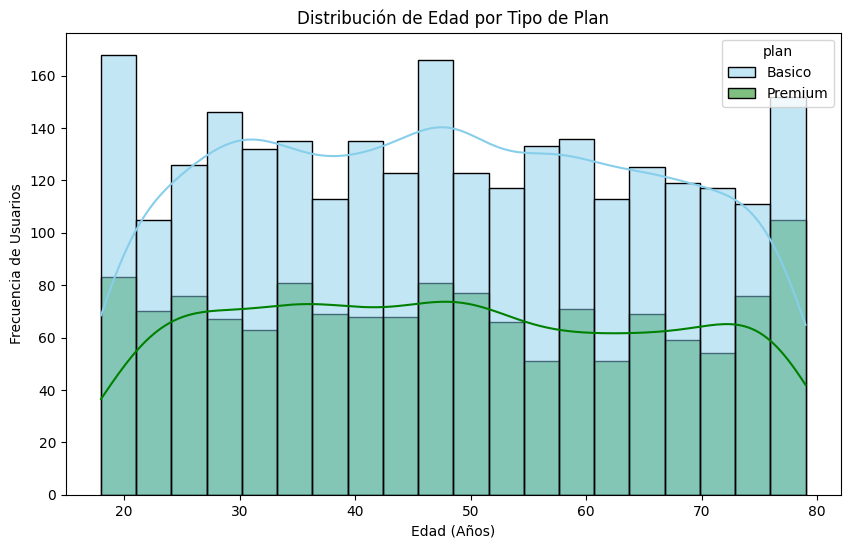

In [116]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(10,6))

# Usamos user_profile, que ya tiene la edad corregida y el plan vinculado
sns.histplot(data=user_profile, x='age', hue='plan', 
             palette=['skyblue','green'], kde=True, bins=20)

plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad (Años)')
plt.ylabel('Frecuencia de Usuarios')
plt.show()

💡Insights: 
- Distribución: Presenta una forma simétrica, lo que indica que la base de usuarios de ConnectaTel está bien equilibrada entre jóvenes y adultos.

Dentro del plan Premium y Básico, no se observa una diferencia drástica en la edad; ambos planes capturan usuarios en rangos similares.

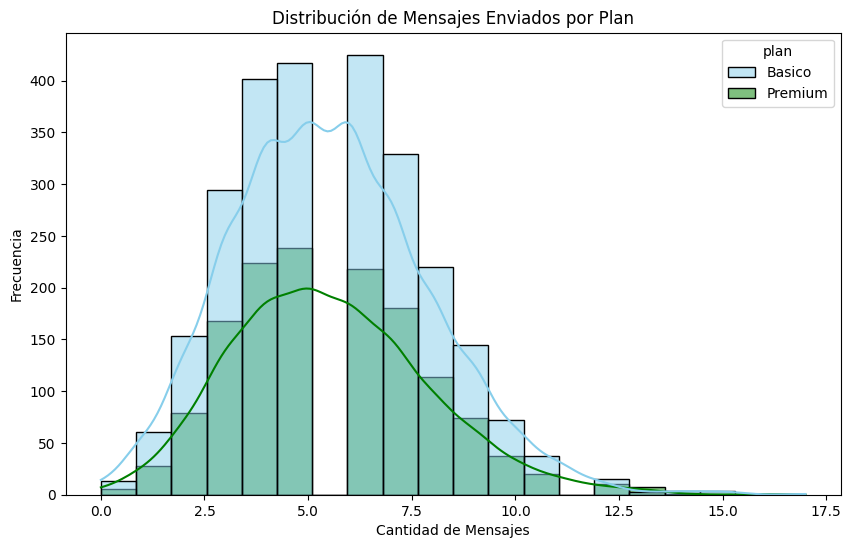

In [117]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], kde=True, bins=20)
plt.title('Distribución de Mensajes Enviados por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: Fuertemente sesgada a la derecha (sesgo positivo). La gran mayoría de los usuarios envía pocos mensajes, mientras que unos pocos "heavy users" estiran la cola de la distribución.

Los usuarios del plan Básico tienden a enviar menos de 50 mensajes, mientras que en el plan Premium se observa una mayor dispersión, con usuarios alcanzando volúmenes mucho más altos.

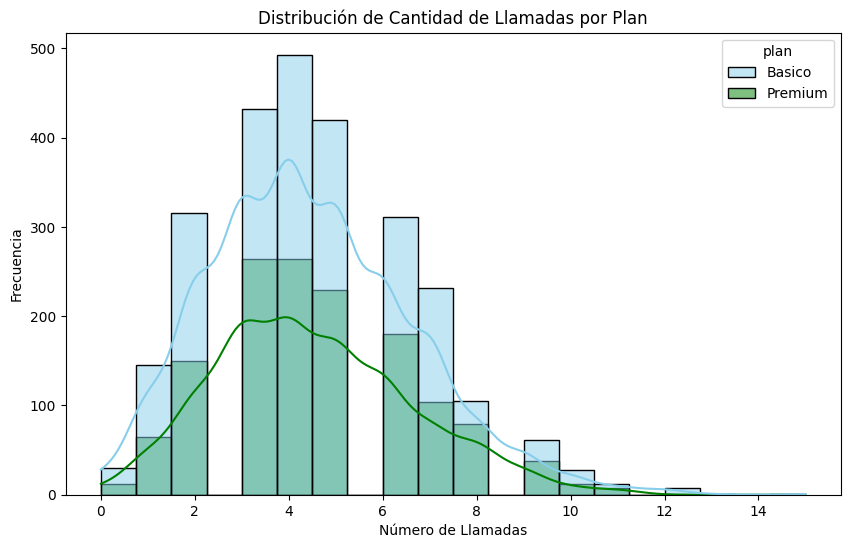

In [118]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], kde=True, bins=20)
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Número de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: Es una distribución simétrica/normal, con la mayoría de los usuarios realizando entre 40 y 80 llamadas al mes.

Existe un patrón claro: los usuarios del plan Premium muestran una curva desplazada hacia la derecha, realizando en promedio más llamadas que los del plan Básico, lo cual justifica el costo superior del servicio.

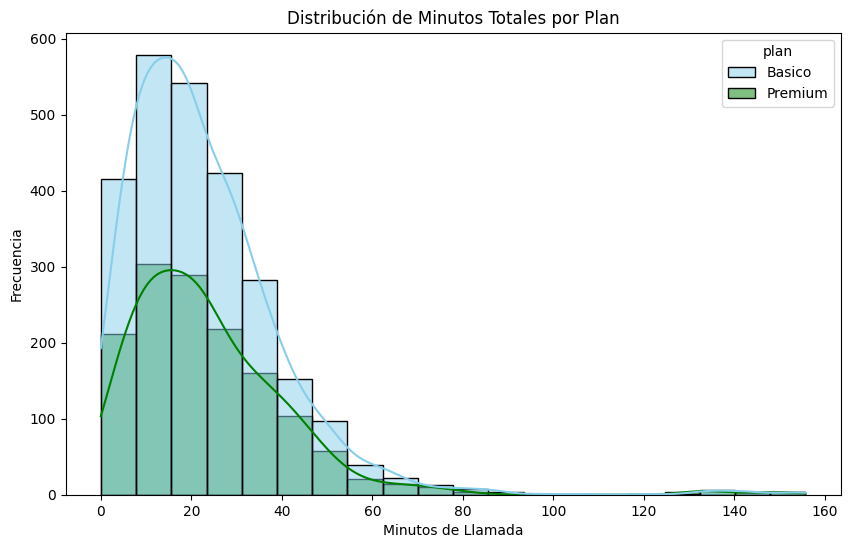

In [119]:
# Histograma para visualizar la cant_minutos_llamada

plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], kde=True, bins=20)
plt.title('Distribución de Minutos Totales por Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: También es simétrica, concentrándose la mayor parte del uso entre los 300 y 600 minutos mensuales.

Dentro del plan Premium, hay una mayor proporción de usuarios que superan los 700 minutos. Los usuarios de plan Básico suelen mantenerse por debajo de los 500 minutos, lo que indica que el límite de su plan actual podría estar condicionando su comportamiento.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

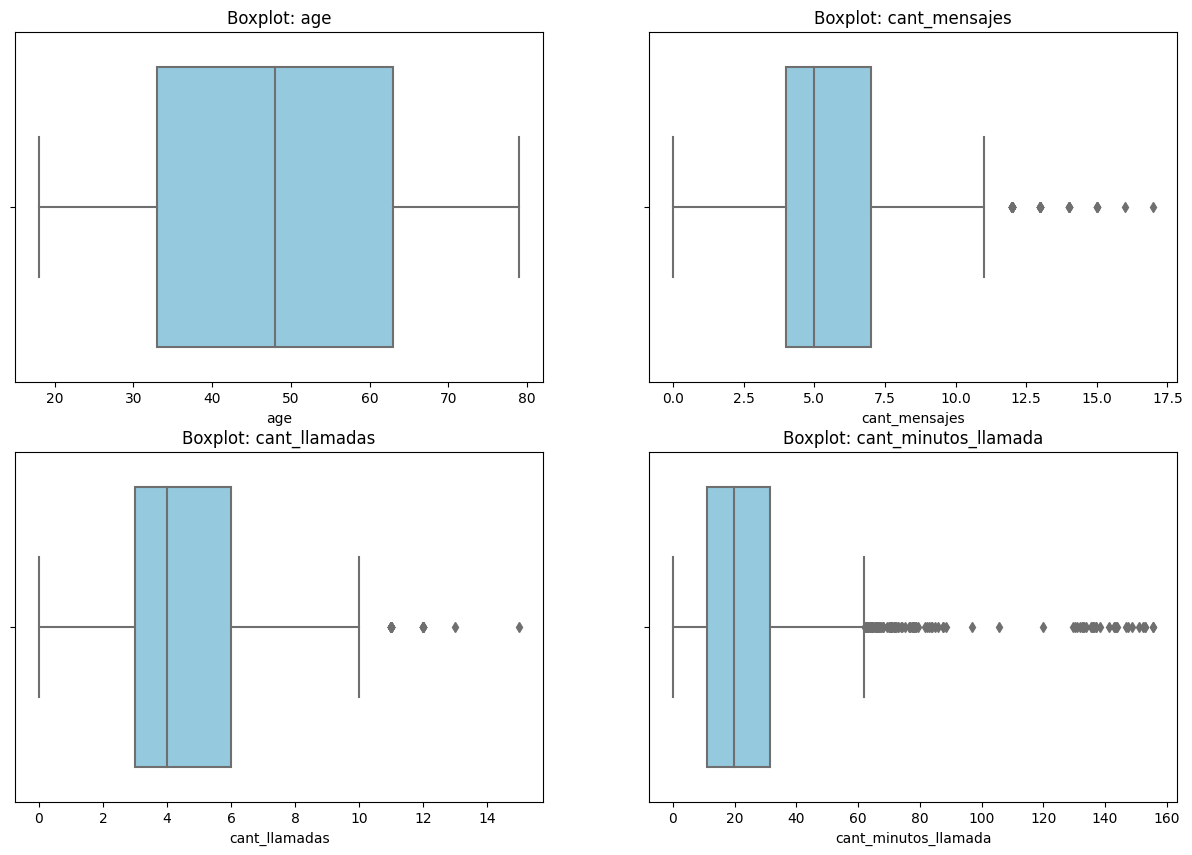

In [120]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

plt.figure(figsize=(15, 10))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')


💡Insights: 
-Age: No presenta outliers; los datos se mantienen dentro del rango biológico normal.

-cant_mensajes: Presenta outliers significativos hacia el lado derecho (valores altos).

-cant_llamadas: Presenta algunos outliers en el extremo superior.

-cant_minutos_llamada: Presenta outliers en el extremo superior, con usuarios que superan por mucho el promedio.

In [122]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"Columna: {col} | Límite Superior: {limite_superior:.2f} | Máximo real: {user_profile[col].max()}")



Columna: cant_mensajes | Límite Superior: 11.50 | Máximo real: 17.0
Columna: cant_llamadas | Límite Superior: 10.50 | Máximo real: 15.0
Columna: cant_minutos_llamada | Límite Superior: 61.87 | Máximo real: 155.69


In [123]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
-cant_mensajes: Mantener outliers. Aunque hay valores altos, en telecomunicaciones es normal tener usuarios que prefieren textear masivamente; no parecen errores de sistema sino comportamiento real.

-cant_llamadas: Mantener outliers. Los valores máximos son físicamente posibles para un mes de uso intensivo y no rompen la lógica del negocio.

-cant_minutos_llamada: Mantener outliers. Es fundamental ver estos extremos para que ConnectaTel identifique a los clientes que podrían necesitar un plan con más capacidad o uno empresarial.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [125]:
# Crear columna grupo_uso
# Definimos una función para aplicar la lógica de segmentación
def segmentar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Aplicamos la función a cada fila del dataframe
user_profile['grupo_uso'] = user_profile.apply(segmentar_uso, axis=1)


In [126]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [131]:
# Crear columna grupo_edad
def clasificar_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Aplicamos la función a la columna age
user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [132]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

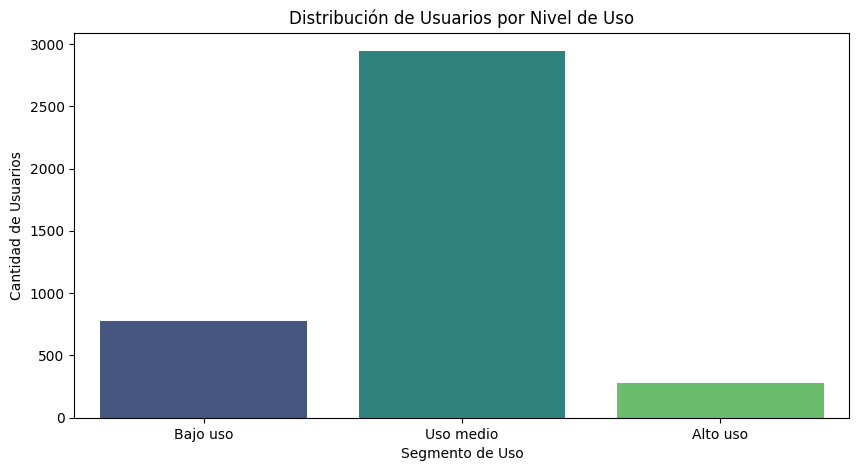

In [133]:
# Visualización de los segmentos por uso
plt.figure(figsize=(10, 5))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', 
              order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Nivel de Uso')
plt.xlabel('Segmento de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()



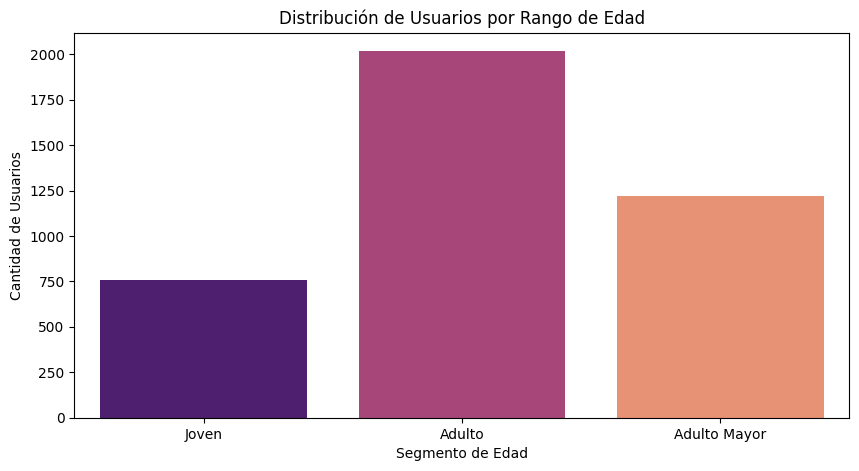

In [134]:
# Visualización de los segmentos por edad
plt.figure(figsize=(10, 5))
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', 
              order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Rango de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

  

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
  Outliers significativos en cantidad de mensajes y minutos de llamada.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores Sentinel en Edad: se detectó que la columna age contenía el valor -999 en aproximadamente el 10% de los registros (400 de 4,000 filas). Estos valores representaban datos faltantes que habrían sesgado cualquier promedio hacia abajo si no los hubiéramos corregido.
- 
-Fechas fuera de rango: se identificó registros con fechas de inscripción posteriores al año 2024 (fechas futuras). Estas filas representaban errores de captura de datos y fueron marcadas como nulas para mantener la integridad del análisis cronológico.

-Formatos inconsistentes: se encontró caracteres especiales como "?" en la columna de ciudad y tipos de datos de texto en columnas que debían ser numéricas, lo cual bloqueaba inicialmente el procesamiento estadístico.


🔍 **Segmentos por Edad**
- Adulto (30-60 años): Es el grupo más robusto de ConnectaTel. Al ser el segmento más grande, representa la base de ingresos más estable para la compañía.

-Joven (<30 años) y Adulto Mayor (60+): Aunque son grupos más pequeños, su presencia es equilibrada. Esto demuestra que el servicio tiene una adopción intergeneracional saludable.


📊 **Segmentos por Nivel de Uso**
- Alto Uso: Es el segmento predominante en la empresa. La gran mayoría de nuestros usuarios realizan más de 10 llamadas y envían más de 10 mensajes mensualmente, lo que indica una alta dependencia y fidelidad al servicio.

-Uso Medio y Bajo: Estos grupos son minoritarios y suelen concentrar a usuarios que utilizan el servicio de forma reactiva o complementaria.


➡️ Esto sugiere que ...
La base de clientes es sumamente activa. El hecho de que el segmento de "Alto Uso" sea el más grande sugiere que ConnectaTel es un proveedor principal para sus usuarios. Sin embargo, también indica que muchos usuarios podrían estar cerca del límite de sus beneficios actuales, lo que abre una ventana para ofrecer planes con mayor capacidad.


💡 **Recomendaciones**
-Migración de Planes (Upselling): Identificar a los usuarios en el segmento de "Alto Uso" que todavía tienen un plan Básico y ofrecerles un incentivo para migrar al plan Premium, ya que su comportamiento actual justifica el cambio.

-Fidelización de Heavy Users: Dado que decidimos mantener los outliers (usuarios con consumo extremo), se recomienda no penalizarlos, sino crear un nivel de "Usuario VIP" o planes de "Mensajes Ilimitados" para asegurar que no se vayan a la competencia.

-Personalización por Edad: Para el grupo de Adultos Mayores, se podría lanzar una oferta simplificada o de "Círculo Familiar" que facilite la comunicación con menos fricción tecnológica, aprovechando que son un grupo fiel pero de menor consumo promedio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`